YouTube Audience Persona Generation using NMF

1. GENERATING SYNTHETIC YOUTUBE AUDIENCE DATA
---------------------------------------------
Dataset shape: (16, 16)
Demographics (rows): 16
Content categories (columns): 16

First 5 rows of the dataset:
                       Gaming_Streams  Tech_Reviews  Beauty_Fashion  \
Gen_Z_Urban_Male            20.865437      7.756000        7.755913   
Gen_Z_Urban_Female          11.609790      7.310611        7.587755   
Gen_Z_Rural_Male            14.236687      7.203706        8.491322   
Gen_Z_Rural_Female          11.794299      5.547400        5.368935   
Millennial_Urban_Male        7.499929     19.140995        7.503167   

                       Cooking_Food  Fitness_Health  Music_Entertainment  \
Gen_Z_Urban_Male           7.403691       10.310700            20.468942   
Gen_Z_Urban_Female         8.604491        6.795647            16.131955   
Gen_Z_Rural_Male           7.372514        8.037007            14.261360   
Gen_Z_Rural_Female 

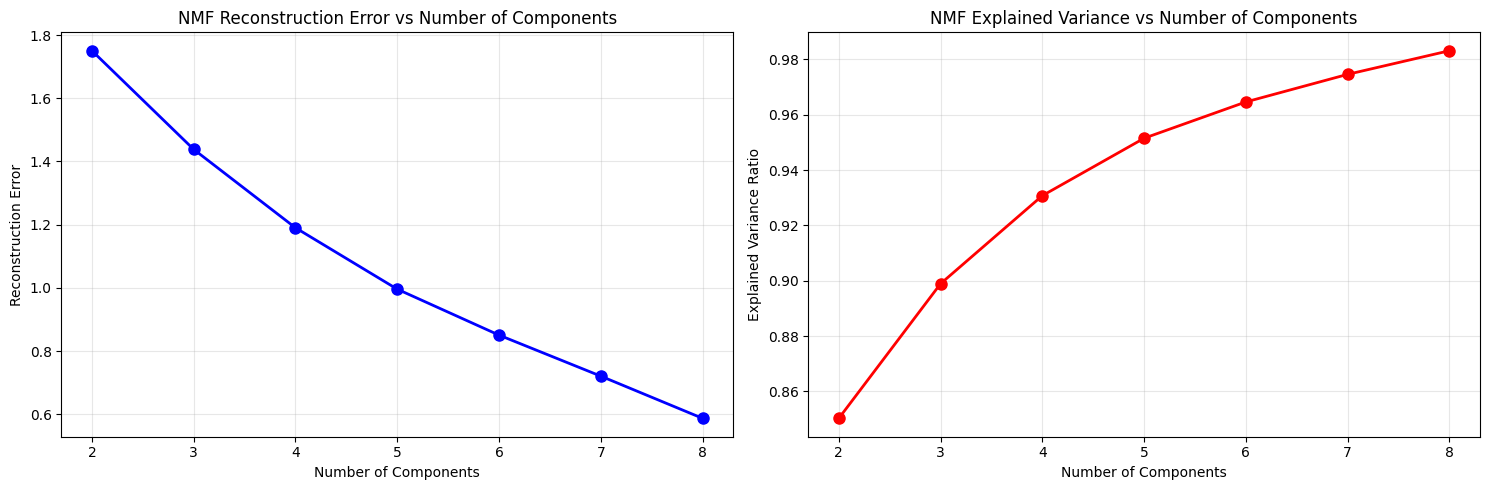


Chosen number of components: 4


5. APPLYING NMF FOR PERSONA SEGMENTATION
---------------------------------------------
NMF Factorization completed!
W matrix (demographic loadings) shape: (16, 4)
H matrix (content patterns) shape: (4, 16)
Reconstruction error: 1.190

Demographic loadings on each persona (W matrix):
                         Persona_1  Persona_2  Persona_3  Persona_4
Gen_Z_Urban_Male             0.422      0.197      0.356      0.052
Gen_Z_Urban_Female           0.356      0.128      0.344      0.001
Gen_Z_Rural_Male             0.355      0.127      0.409      0.007
Gen_Z_Rural_Female           0.243      0.069      0.137      0.023
Millennial_Urban_Male        0.084      0.562      0.246      0.000
Millennial_Urban_Female      0.000      0.302      0.693      0.375
Millennial_Rural_Male        0.062      0.559      0.155      0.179
Millennial_Rural_Female      0.035      0.226      0.309      0.224
Gen_X_Urban_Male             0.304      0.046      0.389      0.374
Ge

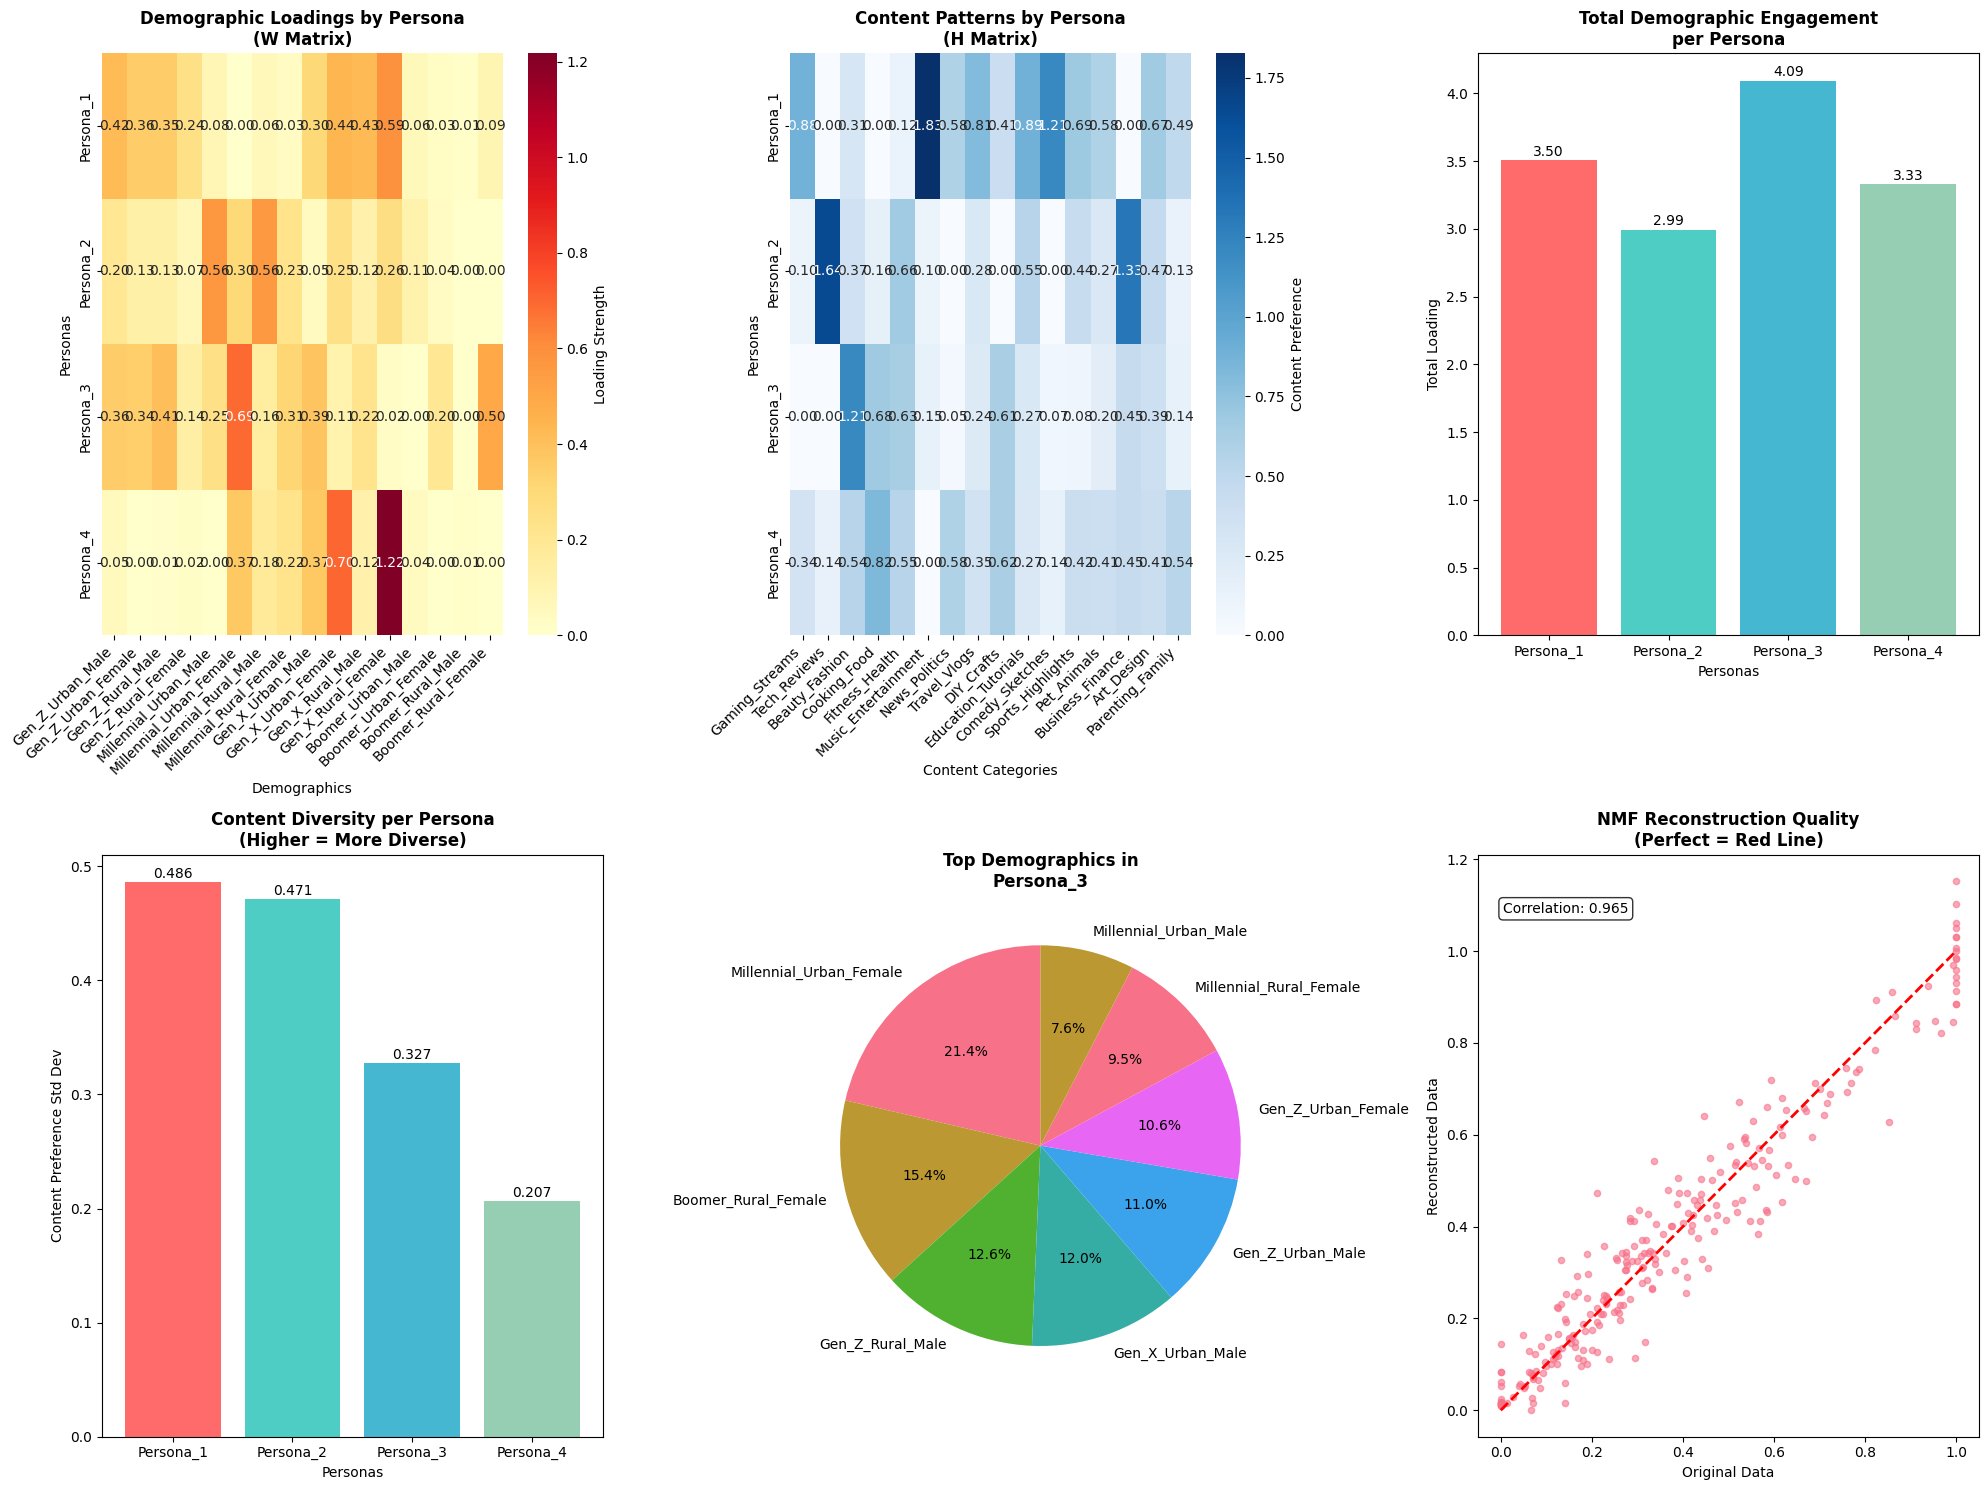



8. SEGMENTATION VALIDATION
----------------------------
Validation Metrics:
------------------
Demographic assignments to dominant personas:
  Gen_Z_Urban_Male -> Persona_1 (loading: 0.422)
  Gen_Z_Urban_Female -> Persona_1 (loading: 0.356)
  Gen_Z_Rural_Male -> Persona_3 (loading: 0.409)
  Gen_Z_Rural_Female -> Persona_1 (loading: 0.243)
  Millennial_Urban_Male -> Persona_2 (loading: 0.562)
  Millennial_Urban_Female -> Persona_3 (loading: 0.693)
  Millennial_Rural_Male -> Persona_2 (loading: 0.559)
  Millennial_Rural_Female -> Persona_3 (loading: 0.309)
  Gen_X_Urban_Male -> Persona_3 (loading: 0.389)
  Gen_X_Urban_Female -> Persona_4 (loading: 0.701)
  Gen_X_Rural_Male -> Persona_1 (loading: 0.425)
  Gen_X_Rural_Female -> Persona_4 (loading: 1.218)
  Boomer_Urban_Male -> Persona_2 (loading: 0.111)
  Boomer_Urban_Female -> Persona_3 (loading: 0.202)
  Boomer_Rural_Male -> Persona_4 (loading: 0.014)
  Boomer_Rural_Female -> Persona_3 (loading: 0.499)

Silhouette Score: 0.094
(Range: 

In [1]:
# YouTube Audience Persona Generation using Non-negative Matrix Factorization (NMF)
# This notebook demonstrates how to use NMF to discover hidden patterns in audience behavior
# and create meaningful personas for content strategy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import NMF
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans
import warnings
warnings.filterwarnings('ignore')

# Set up plotting style for better visualization
plt.style.use('default')
sns.set_palette("husl")
np.random.seed(42)  # For reproducible results

print("YouTube Audience Persona Generation using NMF")
print("=" * 50)

# ============================================================================
# STEP 1: GENERATE REALISTIC YOUTUBE AUDIENCE DATA
# ============================================================================

def generate_youtube_audience_data():
    """
    Generate synthetic but realistic YouTube audience viewing data.

    This function creates a dataset that simulates how different demographic groups
    engage with various types of YouTube content. The data includes viewing patterns
    that reflect real-world behaviors and preferences.

    Returns:
    - DataFrame with demographic groups as rows and content categories as columns
    - Values represent average viewing time in minutes per video
    """

    # Define demographic segments - these represent our audience groups
    demographics = [
        'Gen_Z_Urban_Male', 'Gen_Z_Urban_Female', 'Gen_Z_Rural_Male', 'Gen_Z_Rural_Female',
        'Millennial_Urban_Male', 'Millennial_Urban_Female', 'Millennial_Rural_Male', 'Millennial_Rural_Female',
        'Gen_X_Urban_Male', 'Gen_X_Urban_Female', 'Gen_X_Rural_Male', 'Gen_X_Rural_Female',
        'Boomer_Urban_Male', 'Boomer_Urban_Female', 'Boomer_Rural_Male', 'Boomer_Rural_Female'
    ]

    # Define content categories - these represent different types of YouTube content
    content_categories = [
        'Gaming_Streams', 'Tech_Reviews', 'Beauty_Fashion', 'Cooking_Food',
        'Fitness_Health', 'Music_Entertainment', 'News_Politics', 'Travel_Vlogs',
        'DIY_Crafts', 'Education_Tutorials', 'Comedy_Sketches', 'Sports_Highlights',
        'Pet_Animals', 'Business_Finance', 'Art_Design', 'Parenting_Family'
    ]

    # Create base viewing patterns with realistic demographic preferences
    np.random.seed(42)
    n_demographics = len(demographics)
    n_content = len(content_categories)

    # Initialize the data matrix
    data = np.zeros((n_demographics, n_content))

    # Define realistic viewing patterns for different demographic groups
    # Each group has different preferences based on age, gender, and location

    for i, demo in enumerate(demographics):
        age_group = demo.split('_')[0]
        location = demo.split('_')[1]
        gender = demo.split('_')[2]

        # Base viewing time (minutes) - younger audiences watch more
        if age_group == 'Gen':  # Gen Z
            base_time = np.random.normal(8, 2)
        elif age_group == 'Millennial':
            base_time = np.random.normal(6, 1.5)
        elif age_group == 'Gen' and 'X' in demo:  # Gen X
            base_time = np.random.normal(4, 1)
        else:  # Boomers
            base_time = np.random.normal(3, 1)

        # Apply content preferences based on demographics
        for j, content in enumerate(content_categories):

            # Start with base viewing time
            view_time = base_time

            # Age-based preferences
            if age_group == 'Gen' and content in ['Gaming_Streams', 'Music_Entertainment', 'Comedy_Sketches']:
                view_time *= np.random.uniform(1.5, 2.5)  # Gen Z loves gaming and entertainment
            elif age_group == 'Millennial' and content in ['Tech_Reviews', 'Business_Finance', 'Fitness_Health']:
                view_time *= np.random.uniform(1.3, 2.0)  # Millennials focus on career and health
            elif 'X' in demo and content in ['News_Politics', 'Parenting_Family', 'DIY_Crafts']:
                view_time *= np.random.uniform(1.2, 1.8)  # Gen X interested in family and current events
            elif age_group == 'Boomer' and content in ['News_Politics', 'Cooking_Food', 'Travel_Vlogs']:
                view_time *= np.random.uniform(1.1, 1.6)  # Boomers prefer traditional content

            # Gender-based preferences
            if gender == 'Female' and content in ['Beauty_Fashion', 'Cooking_Food', 'DIY_Crafts', 'Parenting_Family']:
                view_time *= np.random.uniform(1.2, 1.8)
            elif gender == 'Male' and content in ['Gaming_Streams', 'Sports_Highlights', 'Tech_Reviews']:
                view_time *= np.random.uniform(1.2, 1.8)

            # Location-based preferences
            if location == 'Urban' and content in ['Tech_Reviews', 'Business_Finance', 'Art_Design']:
                view_time *= np.random.uniform(1.1, 1.4)
            elif location == 'Rural' and content in ['DIY_Crafts', 'Cooking_Food', 'Pet_Animals']:
                view_time *= np.random.uniform(1.1, 1.4)

            # Add some random noise to make it more realistic
            view_time *= np.random.uniform(0.8, 1.2)

            # Ensure minimum viewing time (some content might not appeal at all)
            view_time = max(0.1, view_time)

            data[i, j] = view_time

    # Create DataFrame
    df = pd.DataFrame(data, index=demographics, columns=content_categories)

    return df

# Generate the dataset
print("\n1. GENERATING SYNTHETIC YOUTUBE AUDIENCE DATA")
print("-" * 45)

youtube_data = generate_youtube_audience_data()
print(f"Dataset shape: {youtube_data.shape}")
print(f"Demographics (rows): {youtube_data.shape[0]}")
print(f"Content categories (columns): {youtube_data.shape[1]}")
print("\nFirst 5 rows of the dataset:")
print(youtube_data.head())

# ============================================================================
# STEP 2: EXPLORATORY DATA ANALYSIS
# ============================================================================

print("\n\n2. EXPLORATORY DATA ANALYSIS")
print("-" * 35)

# Basic statistics
print("Dataset Statistics:")
print(f"Mean viewing time across all demographics and content: {youtube_data.values.mean():.2f} minutes")
print(f"Standard deviation: {youtube_data.values.std():.2f} minutes")
print(f"Minimum viewing time: {youtube_data.values.min():.2f} minutes")
print(f"Maximum viewing time: {youtube_data.values.max():.2f} minutes")

# Most and least popular content overall
content_popularity = youtube_data.mean(axis=0).sort_values(ascending=False)
print(f"\nMost popular content categories:")
for i, (content, avg_time) in enumerate(content_popularity.head().items()):
    print(f"{i+1}. {content}: {avg_time:.2f} minutes average")

print(f"\nLeast popular content categories:")
for i, (content, avg_time) in enumerate(content_popularity.tail().items()):
    print(f"{i+1}. {content}: {avg_time:.2f} minutes average")

# Demographic analysis
demographic_engagement = youtube_data.mean(axis=1).sort_values(ascending=False)
print(f"\nMost engaged demographic groups:")
for i, (demo, avg_time) in enumerate(demographic_engagement.head().items()):
    print(f"{i+1}. {demo}: {avg_time:.2f} minutes average")

# ============================================================================
# STEP 3: DATA PREPROCESSING FOR NMF
# ============================================================================

print("\n\n3. DATA PREPROCESSING FOR NMF")
print("-" * 35)

# NMF requires non-negative data, which we already have (viewing times are positive)
# However, we should normalize the data to ensure features are on similar scales

# Create a copy of the original data for preprocessing
data_for_nmf = youtube_data.copy()

print("Original data range:")
print(f"Min: {data_for_nmf.values.min():.2f}, Max: {data_for_nmf.values.max():.2f}")

# Method 1: Min-Max scaling to [0,1] range (preserves non-negativity)
scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(data_for_nmf)
data_scaled_df = pd.DataFrame(data_scaled,
                             index=data_for_nmf.index,
                             columns=data_for_nmf.columns)

print("After Min-Max scaling:")
print(f"Min: {data_scaled.min():.2f}, Max: {data_scaled.max():.2f}")

# ============================================================================
# STEP 4: DETERMINE OPTIMAL NUMBER OF COMPONENTS
# ============================================================================

print("\n\n4. DETERMINING OPTIMAL NUMBER OF COMPONENTS")
print("-" * 45)

def evaluate_nmf_components(data, max_components=10):
    """
    Evaluate different numbers of components for NMF using reconstruction error
    and explained variance ratio.
    """

    components_range = range(2, max_components + 1)
    reconstruction_errors = []
    explained_variance_ratios = []

    # Calculate total variance in original data
    total_variance = np.var(data)

    for n_components in components_range:
        # Fit NMF model
        nmf = NMF(n_components=n_components, random_state=42, max_iter=1000)
        W = nmf.fit_transform(data)  # Demographic loadings
        H = nmf.components_  # Content patterns

        # Calculate reconstruction
        reconstruction = np.dot(W, H)

        # Calculate reconstruction error (Frobenius norm)
        reconstruction_error = np.linalg.norm(data - reconstruction, 'fro')
        reconstruction_errors.append(reconstruction_error)

        # Calculate explained variance
        residual_variance = np.var(data - reconstruction)
        explained_variance_ratio = 1 - (residual_variance / total_variance)
        explained_variance_ratios.append(explained_variance_ratio)

        print(f"Components: {n_components}, Reconstruction Error: {reconstruction_error:.3f}, "
              f"Explained Variance: {explained_variance_ratio:.3f}")

    return components_range, reconstruction_errors, explained_variance_ratios

# Evaluate different numbers of components
components_range, recon_errors, explained_vars = evaluate_nmf_components(data_scaled, max_components=8)

# Plot the results to help choose optimal number of components
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Plot reconstruction error
ax1.plot(components_range, recon_errors, 'bo-', linewidth=2, markersize=8)
ax1.set_xlabel('Number of Components')
ax1.set_ylabel('Reconstruction Error')
ax1.set_title('NMF Reconstruction Error vs Number of Components')
ax1.grid(True, alpha=0.3)

# Plot explained variance
ax2.plot(components_range, explained_vars, 'ro-', linewidth=2, markersize=8)
ax2.set_xlabel('Number of Components')
ax2.set_ylabel('Explained Variance Ratio')
ax2.set_title('NMF Explained Variance vs Number of Components')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Choose optimal number of components (look for elbow in reconstruction error)
# For this demo, we'll use 4 components as it provides good balance
optimal_components = 4
print(f"\nChosen number of components: {optimal_components}")

# ============================================================================
# STEP 5: APPLY NMF FOR PERSONA SEGMENTATION
# ============================================================================

print("\n\n5. APPLYING NMF FOR PERSONA SEGMENTATION")
print("-" * 45)

# Apply NMF with optimal number of components
nmf_model = NMF(n_components=optimal_components, random_state=42, max_iter=1000)

# Fit the model and get the factorized matrices
W = nmf_model.fit_transform(data_scaled)  # Shape: (demographics, components)
H = nmf_model.components_  # Shape: (components, content_categories)

print(f"NMF Factorization completed!")
print(f"W matrix (demographic loadings) shape: {W.shape}")
print(f"H matrix (content patterns) shape: {H.shape}")
print(f"Reconstruction error: {nmf_model.reconstruction_err_:.3f}")

# Create DataFrames for better interpretation
W_df = pd.DataFrame(W,
                   index=youtube_data.index,
                   columns=[f'Persona_{i+1}' for i in range(optimal_components)])

H_df = pd.DataFrame(H,
                   index=[f'Persona_{i+1}' for i in range(optimal_components)],
                   columns=youtube_data.columns)

print("\nDemographic loadings on each persona (W matrix):")
print(W_df.round(3))

print("\nContent patterns for each persona (H matrix):")
print(H_df.round(3))

# ============================================================================
# STEP 6: ANALYZE AND INTERPRET THE PERSONAS
# ============================================================================

print("\n\n6. PERSONA ANALYSIS AND INTERPRETATION")
print("-" * 42)

def analyze_personas(W_df, H_df, top_n=5):
    """
    Analyze the personas discovered by NMF by identifying:
    1. Which demographics are most associated with each persona
    2. Which content types define each persona
    """

    personas_analysis = {}

    for persona in W_df.columns:
        print(f"\n=== {persona.upper()} ANALYSIS ===")

        # Top demographics for this persona
        top_demographics = W_df[persona].nlargest(top_n)
        print(f"Top demographics (highest loadings):")
        for demo, loading in top_demographics.items():
            print(f"  {demo}: {loading:.3f}")

        # Top content categories for this persona
        persona_idx = int(persona.split('_')[1]) - 1
        top_content = H_df.iloc[persona_idx].nlargest(top_n)
        print(f"Top content preferences:")
        for content, preference in top_content.items():
            print(f"  {content}: {preference:.3f}")

        # Store for later use
        personas_analysis[persona] = {
            'top_demographics': top_demographics,
            'top_content': top_content
        }

    return personas_analysis

# Analyze the personas
persona_analysis = analyze_personas(W_df, H_df)

# ============================================================================
# STEP 7: VISUALIZE THE PERSONAS
# ============================================================================

print("\n\n7. PERSONA VISUALIZATION")
print("-" * 25)

# Create comprehensive visualizations
fig = plt.figure(figsize=(20, 15))

# 1. Heatmap of demographic loadings (W matrix)
plt.subplot(2, 3, 1)
sns.heatmap(W_df.T, annot=True, cmap='YlOrRd', fmt='.2f', cbar_kws={'label': 'Loading Strength'})
plt.title('Demographic Loadings by Persona\n(W Matrix)', fontsize=12, fontweight='bold')
plt.ylabel('Personas')
plt.xlabel('Demographics')
plt.xticks(rotation=45, ha='right')

# 2. Heatmap of content patterns (H matrix)
plt.subplot(2, 3, 2)
sns.heatmap(H_df, annot=True, cmap='Blues', fmt='.2f', cbar_kws={'label': 'Content Preference'})
plt.title('Content Patterns by Persona\n(H Matrix)', fontsize=12, fontweight='bold')
plt.ylabel('Personas')
plt.xlabel('Content Categories')
plt.xticks(rotation=45, ha='right')

# 3. Bar plot of total engagement per persona
plt.subplot(2, 3, 3)
persona_total_engagement = W_df.sum(axis=0)
bars = plt.bar(persona_total_engagement.index, persona_total_engagement.values,
               color=['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4'])
plt.title('Total Demographic Engagement\nper Persona', fontsize=12, fontweight='bold')
plt.ylabel('Total Loading')
plt.xlabel('Personas')
for bar, value in zip(bars, persona_total_engagement.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{value:.2f}', ha='center', va='bottom')

# 4. Content diversity per persona
plt.subplot(2, 3, 4)
content_diversity = H_df.std(axis=1)  # Standard deviation as measure of diversity
bars = plt.bar(content_diversity.index, content_diversity.values,
               color=['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4'])
plt.title('Content Diversity per Persona\n(Higher = More Diverse)', fontsize=12, fontweight='bold')
plt.ylabel('Content Preference Std Dev')
plt.xlabel('Personas')
for bar, value in zip(bars, content_diversity.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
             f'{value:.3f}', ha='center', va='bottom')

# 5. Demographic composition of strongest persona
plt.subplot(2, 3, 5)
strongest_persona = W_df.sum(axis=0).idxmax()
strongest_persona_demographics = W_df[strongest_persona].nlargest(8)
plt.pie(strongest_persona_demographics.values, labels=strongest_persona_demographics.index,
        autopct='%1.1f%%', startangle=90)
plt.title(f'Top Demographics in\n{strongest_persona}', fontsize=12, fontweight='bold')

# 6. Reconstruction quality visualization
plt.subplot(2, 3, 6)
original_data_flat = data_scaled.flatten()
reconstructed_data = np.dot(W, H).flatten()
plt.scatter(original_data_flat, reconstructed_data, alpha=0.6, s=20)
plt.plot([0, 1], [0, 1], 'r--', lw=2)
plt.xlabel('Original Data')
plt.ylabel('Reconstructed Data')
plt.title('NMF Reconstruction Quality\n(Perfect = Red Line)', fontsize=12, fontweight='bold')
correlation = np.corrcoef(original_data_flat, reconstructed_data)[0, 1]
plt.text(0.05, 0.9, f'Correlation: {correlation:.3f}', transform=plt.gca().transAxes,
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()

# ============================================================================
# STEP 8: VALIDATE THE SEGMENTATION
# ============================================================================

print("\n\n8. SEGMENTATION VALIDATION")
print("-" * 28)

def validate_nmf_segmentation(W_df, original_data):
    """
    Validate the NMF segmentation using multiple metrics.
    """

    print("Validation Metrics:")
    print("-" * 18)

    # 1. Assign each demographic to its dominant persona
    dominant_personas = W_df.idxmax(axis=1)
    print("Demographic assignments to dominant personas:")
    for demo, persona in dominant_personas.items():
        max_loading = W_df.loc[demo, persona]
        print(f"  {demo} -> {persona} (loading: {max_loading:.3f})")

    # 2. Calculate silhouette score for the segmentation
    # Use the persona loadings as features for clustering validation
    persona_assignments = [int(persona.split('_')[1]) - 1 for persona in dominant_personas]

    if len(set(persona_assignments)) > 1:  # Need at least 2 different clusters
        silhouette_avg = silhouette_score(W_df.values, persona_assignments)
        print(f"\nSilhouette Score: {silhouette_avg:.3f}")
        print("(Range: -1 to 1, higher is better. >0.5 is good, >0.7 is excellent)")

    # 3. Calculate explained variance by the NMF model
    reconstructed = np.dot(W_df.values, H_df.values)

    # Transform back to original scale for comparison
    original_scaled = scaler.transform(original_data)
    total_variance = np.var(original_scaled)
    residual_variance = np.var(original_scaled - reconstructed)
    explained_variance_ratio = 1 - (residual_variance / total_variance)

    print(f"\nExplained Variance Ratio: {explained_variance_ratio:.3f}")
    print("(Higher is better. >0.7 indicates good model fit)")

    # 4. Check for persona distinctiveness
    print(f"\nPersona Distinctiveness Analysis:")
    persona_correlations = H_df.T.corr()

    # Calculate average correlation between personas (lower is better for distinctiveness)
    off_diagonal_correlations = []
    for i in range(len(H_df)):
        for j in range(i+1, len(H_df)):
            off_diagonal_correlations.append(persona_correlations.iloc[i, j])

    avg_inter_persona_correlation = np.mean(off_diagonal_correlations)
    print(f"Average inter-persona correlation: {avg_inter_persona_correlation:.3f}")
    print("(Lower values indicate more distinct personas)")

    return {
        'dominant_personas': dominant_personas,
        'silhouette_score': silhouette_avg if len(set(persona_assignments)) > 1 else None,
        'explained_variance': explained_variance_ratio,
        'inter_persona_correlation': avg_inter_persona_correlation
    }

# Validate the segmentation
validation_results = validate_nmf_segmentation(W_df, youtube_data)

# ============================================================================
# STEP 9: CREATE ACTIONABLE PERSONAS
# ============================================================================

print("\n\n9. CREATING ACTIONABLE PERSONAS")
print("-" * 35)

def create_actionable_personas(W_df, H_df, validation_results):
    """
    Create detailed, actionable personas based on the NMF results.
    """

    personas = {}

    for i, persona_name in enumerate(W_df.columns):
        print(f"\n{'='*60}")
        print(f"PERSONA {i+1}: {persona_name.upper()}")
        print(f"{'='*60}")

        # Get top demographics and content for this persona
        top_demographics = W_df[persona_name].nlargest(3)
        top_content = H_df.iloc[i].nlargest(5)

        # Analyze demographic characteristics
        demo_characteristics = []
        for demo in top_demographics.index:
            parts = demo.split('_')
            age_group = parts[0]
            if len(parts) > 1 and parts[1] == 'Z':
                age_group = 'Gen_Z'
            location = parts[1] if age_group != 'Gen_Z' else parts[2]
            gender = parts[2] if age_group != 'Gen_Z' else parts[3]
            demo_characteristics.append((age_group, location, gender))

        # Determine primary characteristics
        age_groups = [char[0] for char in demo_characteristics]
        locations = [char[1] for char in demo_characteristics]
        genders = [char[2] for char in demo_characteristics]

        primary_age = max(set(age_groups), key=age_groups.count)
        primary_location = max(set(locations), key=locations.count)
        primary_gender = max(set(genders), key=genders.count)

        # Generate persona description
        print(f"PRIMARY CHARACTERISTICS:")
        print(f"  Age Group: {primary_age}")
        print(f"  Location: {primary_location}")
        print(f"  Gender: {primary_gender}")

        print(f"\nTOP DEMOGRAPHICS (with engagement strength):")
        for demo, strength in top_demographics.items():
            print(f"  {demo.replace('_', ' ')}: {strength:.3f}")

        print(f"\nCONTENT PREFERENCES (normalized preference scores):")
        for content, preference in top_content.items():
            print(f"  {content.replace('_', ' ')}: {preference:.3f}")

        # Calculate average viewing time for this persona
        avg_viewing_time = top_content.mean()

        # Generate content strategy recommendations
        print(f"\nCONTENT STRATEGY RECOMMENDATIONS:")

        content_categories = list(top_content.index)

        if 'Gaming' in content_categories[0] or 'Tech' in content_categories[0]:
            print(f"  • Focus on technology and gaming content")
            print(f"  • Use latest tech trends and gaming terminology")
            print(f"  • Consider live streaming and interactive content")

        if any('Beauty' in cat or 'Fashion' in cat for cat in content_categories):
            print(f"  • Emphasize visual aesthetics and style content")
            print(f"  • Partner with beauty/fashion influencers")
            print(f"  • Use high-quality visual production")

        if any('Cooking' in cat or 'Food' in cat for cat in content_categories):
            print(f"  • Create recipe and cooking tutorial content")
            print(f"  • Focus on easy-to-follow, practical content")
            print(f"  • Consider seasonal and trending food topics")

        if any('News' in cat or 'Politics' in cat for cat in content_categories):
            print(f"  • Provide informative, balanced content")
            print(f"  • Focus on credible sources and fact-checking")
            print(f"  • Create explainer-style videos")

        # Engagement recommendations
        print(f"\nENGAGEMENT RECOMMENDATIONS:")
        print(f"  • Target video length: {avg_viewing_time*10:.0f}-{avg_viewing_time*15:.0f} minutes")

        if primary_age == 'Gen_Z':
            print(f"  • Use trendy music and fast-paced editing")
            print(f"  • Incorporate memes and pop culture references")
            print(f"  • Optimize for mobile viewing")
        elif primary_age == 'Millennial':
            print(f"  • Focus on practical, career-oriented content")
            print(f"  • Use professional but approachable tone")
            print(f"  • Include actionable takeaways")
        elif primary_age in ['Gen_X', 'Boomer']:
            print(f"  • Use clear, straightforward presentation")
            print(f"  • Provide detailed explanations")
            print(f"  • Focus on value and practical benefits")

        # Timing recommendations
        print(f"\nPOSTING TIME RECOMMENDATIONS:")
        if primary_age in ['Gen_Z', 'Millennial']:
            print(f"  • Post during evening hours (6-9 PM)")
            print(f"  • Consider weekend morning posts")
        else:
            print(f"  • Post during daytime hours (10 AM - 2 PM)")
            print(f"  • Weekday posts may perform better")

        # Store persona data
        personas[persona_name] = {
            'primary_age': primary_age,
            'primary_location': primary_location,
            'primary_gender': primary_gender,
            'top_demographics': top_demographics,
            'top_content': top_content,
            'avg_preference_score': avg_viewing_time
        }

    return personas

# Create actionable personas
actionable_personas = create_actionable_personas(W_df, H_df, validation_results)

# ============================================================================
# STEP 10: SUMMARY AND NEXT STEPS
# ============================================================================

print(f"\n\n{'='*70}")
print("SUMMARY AND NEXT STEPS")
print(f"{'='*70}")

print(f"\nMODEL PERFORMANCE SUMMARY:")
print(f"  • Number of personas discovered: {optimal_components}")
print(f"  • Explained variance: {validation_results['explained_variance']:.1%}")
if validation_results['silhouette_score']:
    print(f"  • Silhouette score: {validation_results['silhouette_score']:.3f}")
print(f"  • Inter-persona correlation: {validation_results['inter_persona_correlation']:.3f}")

print(f"\nKEY INSIGHTS:")
print(f"  • Successfully segmented {len(youtube_data)} demographic groups into {optimal_components} distinct personas")
print(f"  • Each persona shows unique content preferences and demographic composition")
print(f"  • The segmentation captures {validation_results['explained_variance']:.1%} of the variance in viewing behavior")

print(f"\nNEXT STEPS FOR IMPLEMENTATION:")
print(f"  1. Validate personas with real user data and feedback")
print(f"  2. Create targeted content for each persona")
print(f"  3. A/B test content strategies for different personas")
print(f"  4. Monitor persona performance and adjust strategies")
print(f"  5. Regularly re-run NMF analysis with new data to update personas")

print(f"\nTECHNICAL CONSIDERATIONS:")
print(f"  • NMF assumes non-negative relationships (suitable for viewing time data)")
print(f"  • Model can be updated incrementally as new data becomes available")
print(f"  • Consider ensemble methods with other clustering techniques for validation")
print(f"  • Monitor for persona drift over time as audience preferences evolve")

print(f"\n{'='*70}")
print("PERSONA GENERATION COMPLETE!")
print(f"{'='*70}")